# ARI of single-linkage clustering

The separation condition $\Delta_{\mathrm{out}} > \Delta_{\mathrm{in}}$ (Assumption 3) is
*sufficient* for single linkage to recover the true partition. `assumptions.ipynb` measured how
often it holds, and the answer was: not that often past $K = 4$. This notebook asks the converse
question — **how much of the recovery survives where the condition fails?** Nothing here is
conditioned on an assumption being satisfied: the mixture of the first figure is a first draw with
no selection, and the grid of the second one is the same $(\alpha, K)$ grid as in
`assumptions.ipynb`, kept in full.

**What is measured.** The Adjusted Rand Index between the true partition $P^\star$ and the
single-linkage partition, and separately the exact-recovery event $\{\mathrm{ARI} = 1\}$, which is
the event the consistency theorem bounds. ARI is the informative summary in the regime this
notebook is about: it degrades gracefully, so it distinguishes "two clusters merged" from
"partition unrelated to the truth", where the exact-recovery indicator sees only a failure.

**Design.**
* $\Sigma = \{0,\dots,4\}$, first-order chains, transition rows drawn from a Dirichlet($\alpha$)
  prior. $N$ sequences of length $n$ with i.i.d. latent labels, balanced weights $w_k = 1/K$
  (single linkage needs no balance condition). Every sequence starts from its own initial law, the
  Dirac law at a state drawn uniformly on $\Sigma$, as in the other two notebooks.
* Costs fixed in advance, hence deterministic as the theory requires: $c_{\mathrm{sub}} \equiv 2$,
  $\delta \equiv 1$, so $M = 2$.
* **Estimator: single linkage cut at $K$ blocks**, $K$ known. The consistency theorem is stated for
  the cut at a fixed level $t \in (\Delta_{\mathrm{in}}, \Delta_{\mathrm{out}})$, but its proof
  shows that on the event $\mathcal E_{N,n}(\varepsilon)$ the two cuts coincide; cutting at $K$
  avoids an oracle threshold that no practitioner could pick. When a class comes out empty the cut
  is taken at the number of non-empty classes, which is what $P^\star$ counts.
* $\mathrm{ARI}_n$ is evaluated on **nested prefixes** of the same $N$ trajectories, so a curve
  $n \mapsto \mathrm{ARI}_n$ is a genuine sample path of one dataset growing in length, not a
  sequence of independent draws.

**A by-product that costs nothing.** Once the $N \times N$ dissimilarity matrix is computed, the
true labels give a plug-in estimate of $\Gamma$: $\hat\Gamma_{k\ell}$ is the average of
$\hat\gamma_n(i,j)$ over the pairs of the block $(k,\ell)$, whence $\hat\Delta_{\mathrm{in}}$,
$\hat\Delta_{\mathrm{out}}$ and the separation margin $\hat\eta = \hat\Delta_{\mathrm{out}} -
\hat\Delta_{\mathrm{in}}$. The ARI and the margin are therefore measured **on the same data**, and
can be compared cell by cell. Note that this estimator averages over
$|C_k|(|C_k|-1)/2$ or $|C_k||C_\ell|$ pairs, whereas `assumptions.ipynb` uses one pair per block
(two independent realisations per component): it is much less noisy, so its numbers are not
expected to match that notebook digit for digit.

In [1]:
%load_ext autoreload
%autoreload 2

import time

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm



from om_lib import (PAPER_STYLE, SEQUENTIAL_CMAP, adjusted_rand_index,
                    check_assumption_metric, cost_scheme, cut_at_k, kmedoids,
                    largest_gap_k,
                    om_matrices, sample_markov_model, sample_mixture, separation_levels,
                    single_linkage_tree, spectral_gap, stationary_distribution_markov)

/home/ottavio/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup

Every parameter of the notebook is in the first cell below — alphabet and costs, the $(N, n)$
path of the first experiment, the $(\alpha, K)$ grid of the second. The second cell turns them
into a runtime: every dissimilarity matrix costs $\binom{N}{2}$ alignments of $O(n^2)$ each, so a
single constant measured on this machine predicts the whole notebook, and the projected total is
printed against the budget before anything long is started. The third holds the two evaluation
functions the experiments share: one reads a dissimilarity matrix, the other applies it along
nested prefixes of a sample.

In [ ]:
# --------------------------------------------------------------- shared ----
D_STATES     = 5           # alphabet size, Sigma = {0, ..., 4}
SEED         = 20260803
SUB_COST     = 2.0         # c_sub(a, b) for a != b, hence M = 2
INDEL_COST   = 1.0         # delta(a)
EXACT_TOL    = 1e-12       # ARI > 1 - EXACT_TOL is the exact-recovery event {ARI = 1}
MED_RESTARTS = 10          # random restarts of K-medoids, on top of PAM's BUILD
MED_SEED     = 0           # fixed, so the clustering is a function of D alone
BUDGET_HOURS = 200.0       # what the whole notebook is allowed to take, checked below
COL_PATH     = "#1b6ca8"   # the blue of om_convergence.ipynb
COL_GAP      = "#c0392b"   # the red of om_convergence.ipynb, for the largest-gap rule

# ------------------------------- experiment 1: the horizons, at fixed N ----
ALPHA_FIX = 0.3            # moderate randomness: distinguishable chains that still mix fast
K_FIX     = 4              # the largest K where separation still holds most of the time
R_PATH    = 50             # replicates, each running the whole set of horizons
PATH_N    = 800            # sequences, fixed throughout -- the same N as the grid below

#: The horizons, read on nested prefixes of the same PATH_N sequences. Only the length moves,
#: so a curve is one dataset growing in n, and nothing can be lost from one point to the next
#: but sampling noise -- the structure of om_convergence.ipynb and assumptions.ipynb. An
#: earlier version let N grow along with n; the ARI then oscillated between 1 and 0.71,
#: because every added sequence is a fresh chance for single linkage to isolate one of them,
#: spend a cluster on it and merge two true classes. That is a real effect -- the N^2 of the
#: union bound, visible -- but it belongs to a figure of its own, not to a consistency curve.
#: Cost is proportional to sum_g n_g^2, not to the largest horizon, since nested prefixes
#: share no work: the ten horizons cost 3.85 times the last one alone.
PATH_LEN  = np.arange(100, 1001, 100)

# ---------------------------------- experiment 2: the (alpha, K) grid ------
#: Same (alpha, K) grid as `assumptions.ipynb`, run at the same N as the curve above and at
#: its last horizon, both tied to it here rather than transcribed. The grid therefore sits on
#: a point the curve actually visits, and the curve says whether that sample size suffices for
#: at least one mixture. These 72 cells x R_SWEEP repetitions are the entire runtime -- the
#: curve is a rounding error next to them -- and a cell costs O(N^2 n^2) whatever K, so the
#: trade between N, n and R_SWEEP is the only lever. The next cell prints it and refuses a run
#: that does not fit.
ALPHAS  = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 5.0, 10.0])
KS      = [2, 3, 4, 5, 6, 7, 8, 9, 10]
N_SWEEP = PATH_N                                              # the same N as the curve
#: A single horizon: a secondary one costs its own n^2 -- nested prefixes share no work --
#: and the ARI it would add is already read along the path above, at eleven lengths instead
#: of two.
GRID_N  = np.array([PATH_LEN[-1]])                            # the path's last n
R_SWEEP = 30                                                 # repetitions per cell
LAST    = GRID_N.size - 1        # index of the largest horizon, the one the figures show

# --------------------------------------------------------------------------
S_COST, DELTA_COST = cost_scheme("constant", D_STATES, sub=SUB_COST, indel=INDEL_COST)
assert all(v for k, v in check_assumption_metric(S_COST, DELTA_COST).items()
           if k != "M = max c_sub")

In [3]:
#: What the raw alignment rate misses: sampling the mixture, Kruskal's algorithm in pure
#: Python, and the memory traffic of an N x N matrix. Calibrated on the run of 2026-08-03 --
#: 1080 matrices at N = 800 over the horizons (400, 800), 37753 s, i.e. 35.0 s each against
#: the 30.0 s the corrected model predicts.
OVERHEAD = 1.17


def measure_rate(N=120, n=400, seed=0):
    """Seconds per unit of N^2 n^2, measured on this machine.

    The kernels are compiled first, since numba's first call would otherwise be timed instead
    of the work. Beware that this measures the machine as it is right now: the raw figure has
    been seen to move by 40% between two moments of the same day depending on the load, and
    the projections below move with it.
    """
    rng = np.random.default_rng(seed)
    om_matrices(rng.integers(D_STATES, size=(8, 40)), [40], S_COST, DELTA_COST)  # warm up
    X = rng.integers(D_STATES, size=(N, n))
    t0 = time.perf_counter()
    om_matrices(X, [n], S_COST, DELTA_COST)
    return (time.perf_counter() - t0) / (float(N) ** 2 * float(n) ** 2)


RATE = measure_rate() * OVERHEAD


def cost(N, ns):
    """Seconds for one N x N dissimilarity matrix evaluated over the horizons `ns`.

    Nested prefixes are *not* free. `_om_matrix_kernel` calls `om_distance` once per horizon
    and per pair -- the two-row dynamic program keeps no table to snapshot, so the value at
    length n cannot be read off a longer run -- and a matrix therefore costs the SUM of the
    n^2 over the grid, not the largest of them. For the eleven horizons of the path that sum
    is 3.9 times its last point alone, which is why a single replicate takes about twelve
    minutes and not three.
    """
    ns = np.atleast_1d(np.asarray(ns, dtype=float))
    return RATE * float(N) ** 2 * float((ns ** 2).sum())


path_s = R_PATH * cost(PATH_N, PATH_LEN)
cell_s = cost(N_SWEEP, GRID_N)                     # one repetition of one grid cell
grid_s = len(ALPHAS) * len(KS) * R_SWEEP * cell_s
alone = cost(N_SWEEP, GRID_N[-1:]) * len(ALPHAS) * len(KS) * R_SWEEP

print(f"rate: {cost(400, 400):.1f}s for one 400 x 400 matrix at n = 400 "
      f"(raw x {OVERHEAD} overhead)\n")
print(f"curve  {R_PATH:>3} replicates x (N = {PATH_N}, {PATH_LEN.size} horizons)"
      f"{'':>3}{path_s / 3600:>7.2f} h  ({cost(PATH_N, PATH_LEN) / 60:.0f} min each)")
print(f"grid   {len(ALPHAS) * len(KS)} cells x {R_SWEEP} reps x (N = {N_SWEEP}, "
      f"n = {', '.join(str(v) for v in GRID_N)}){'':>1}{grid_s / 3600:>7.2f} h "
      f"({cell_s:.0f}s each)")
if GRID_N.size > 1:
    print(f"{'':>7}of which the shortest horizons cost{'':>13}{(grid_s - alone) / 3600:>7.2f} h")
print(f"total{'':>44}{(path_s + grid_s) / 3600:>7.2f} h "
      f"= {(path_s + grid_s) / 86400:.1f} days,  budget {BUDGET_HOURS:.0f} h")

if path_s + grid_s > 3600 * BUDGET_HOURS:
    raise ValueError("over budget: lower R_SWEEP or N_SWEEP, or shorten the secondary "
                     "horizons -- their cost is quadratic, so halving one quarters it")

rate: 1.9s for one 400 x 400 matrix at n = 400 (raw x 1.17 overhead)

curve    1 replicates x (N = 800, 10 horizons)      0.05 h  (3 min each)
grid   72 cells x 30 reps x (N = 800, n = 1000)   29.19 h (49s each)
total                                              29.24 h = 1.2 days,  budget 200 h


In [4]:
#: everything `evaluate_matrix` returns, in the order the sweeps store it
EVAL_KEYS = ("ari", "ari_medoids", "ari_k_hat", "k_hat", "in", "out", "out_max")


def evaluate_matrix(D, labels, K):
    """ARI of two single-linkage partitions, and plug-in separation levels, from one matrix.

    Both partitions come from the same tree, so the second one is free -- the merge heights
    are already there:

    * `ari`, the cut at the number of non-empty classes, i.e. the number of blocks of P*.
      This is the estimator the consistency theorem is about, and it assumes K known.
    * `ari_k_hat`, the cut at `k_hat`, the largest-gap estimator of K of equation (4.4). This
      is what one can do without knowing K, and it is the quantity Assumption 4 governs.

    A third partition, `ari_medoids`, comes from K-medoids on the same matrix -- a different
    algorithm rather than a different cut, and the one Assumption 5 (balance) governs. With the
    balanced weights used here that condition reads Delta_out > 2 Delta_in, i.e. exactly
    Assumption 4(a), which is far more demanding than the Delta_out > Delta_in single linkage
    needs; the comparison is the point.

    Returns the three ARIs, k_hat, and Delta_in, Delta_out, Delta_out^max.
    """
    K_eff = int(np.unique(labels).size)
    heights, edges = single_linkage_tree(D)
    k_hat = largest_gap_k(heights)
    med_labels, _, _ = kmedoids(D, K_eff, np.random.default_rng(MED_SEED),
                                n_restarts=MED_RESTARTS)
    out = {"ari": adjusted_rand_index(cut_at_k(edges, D.shape[0], K_eff), labels),
           "ari_medoids": adjusted_rand_index(med_labels, labels),
           "k_hat": float(k_hat),
           "ari_k_hat": adjusted_rand_index(cut_at_k(edges, D.shape[0], k_hat), labels)}
    out.update(separation_levels(D, labels, K))
    return out


def evaluate_paths(X, labels, grid, K):
    """`evaluate_matrix` along nested prefixes of X: arrays indexed by the horizon grid."""
    Ds = om_matrices(X, grid, S_COST, DELTA_COST)
    out = {key: np.empty(len(grid)) for key in EVAL_KEYS}
    for g in range(len(grid)):
        ev = evaluate_matrix(Ds[g], labels, K)
        for key in out:
            out[key][g] = ev[key]
    return out

## The ARI along nested prefixes, at fixed $N$

**What the bound says.** The exact-recovery bound of the paper is
$N^2\exp(-\varepsilon^2 n/(2C^\star))$, with $\varepsilon = \eta/2$ and
$C^\star = C_{\mathrm{Pau}}M^2\tau_{\mathrm{mix}}$. At a fixed number of sequences it decays
exponentially in the length, which is the statement this figure illustrates: $N = 800$ throughout
— the same $N$ as the grid below — and only the horizon moves.

**Design.** Ten horizons, $n = 100, 200, \dots, 1000$, read on **nested prefixes of the same
$N$ sequences**: a replicate draws its $800$ sequences once, at full length, and every point of
the curve reads them at a shorter prefix. A curve is therefore a genuine sample path of one
dataset growing in length, exactly as in `om_convergence.ipynb` and `assumptions.ipynb`, and not
a sequence of independent draws. Nothing can be lost from one point to the next but sampling
noise, so a drop is a property of the data and never an artefact of the design.

The cost is $\sum_g n_g^2$ and not the largest horizon, since nested prefixes share no work —
`om_matrices` re-runs the alignment at every length — so the ten of them cost $3.85$ times the
last one alone.

**Why $N$ is fixed, and what it costs.** An earlier version let $N$ grow along with $n$. The
individual curves then oscillated between $1$ and $\approx 0.71$ instead of increasing: every
sequence added to the sample is a fresh chance for single linkage to isolate one of them, and an
isolated sequence consumes one of the $K$ blocks, so two true classes have to merge. With $K = 4$
balanced classes that failure costs exactly $\mathrm{ARI} = 0.712$, which is the level the curves
kept falling back to. The effect is real — it is the $N^2$ of the union bound, visible to the
naked eye — but it is a statement about $N$, not about consistency in $n$, and it deserves its
own figure rather than a confound in this one.

**Fixed mixture.** $K = 4$, $\alpha = 0.3$, the $K$ kernels drawn once (first draw, no
selection); across replicates only the labels and the trajectories are redrawn, so everything the
bound depends on besides $n$ is held constant. $K = 4$ is the largest $K$ at which
`assumptions.ipynb` still found the separation condition satisfied most of the time — the edge of
the region the theory covers — and $\alpha = 0.3$ keeps the chains distinguishable while still
mixing fast.

**Replicates.** $R = 50$, all drawn as thin lines with the mean on top, the charte of
`om_convergence.ipynb`: the spread between them is the variability of a single experiment, not an
interval around a mean.

**A caveat on reading the two summaries.** In this regime the ARI is not a graded measure. It
takes essentially two values — $1$ when the partition is recovered, $\approx 0.71$ when one
sequence is isolated — so the mean ARI is very nearly an affine function of the exact-recovery
rate, $\overline{\mathrm{ARI}} \approx 0.71 + 0.29\,\hat{\mathbb P}(\mathrm{ARI}=1)$. The two
columns of the table below should be compared rather than presented as independent measurements.

In [5]:
rng = np.random.default_rng(SEED)
KERNELS = np.stack([sample_markov_model(D_STATES, 1, ALPHA_FIX, rng)["transitions"]
                    for _ in range(K_FIX)])

gaps = np.array([spectral_gap(P) for P in KERNELS])
print("spectral gaps    :", np.round(gaps, 3))
print("relaxation times :", np.round(1.0 / gaps, 1))
print("stationary laws  :\n", np.round(np.stack([stationary_distribution_markov(P)
                                                 for P in KERNELS]), 3))
print(f"\nhorizons : {PATH_LEN.tolist()}   at the fixed N = {PATH_N}")

# where this mixture sits with respect to the separation condition, at a reference horizon
ref_mix = sample_mixture(K_FIX, 100, 800, D_STATES, ALPHA_FIX, rng, kernels=KERNELS)
ref = evaluate_paths(ref_mix["X"], ref_mix["labels"], [800], K_FIX)
print(f"\nat n = 800, N = 100: Delta_in = {ref['in'][0]:.3f}, Delta_out = {ref['out'][0]:.3f}, "
      f"margin = {ref['out'][0] - ref['in'][0]:+.3f}, ARI = {ref['ari'][0]:.3f}")

spectral gaps    : [0.383 0.293 0.222 0.232]
relaxation times : [2.6 3.4 4.5 4.3]
stationary laws  :
 [[0.205 0.129 0.529 0.061 0.076]
 [0.098 0.104 0.266 0.117 0.415]
 [0.084 0.209 0.124 0.19  0.393]
 [0.098 0.04  0.381 0.079 0.402]]

horizons : [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]   at the fixed N = 800

at n = 800, N = 100: Delta_in = 0.730, Delta_out = 0.822, margin = +0.092, ARI = 1.000


In [6]:
print(f"{'':<8}{'N':>6}{'n':>7}{'matrices':>10}{'hours':>8}")
for t in range(PATH_LEN.size):
    last = t == PATH_LEN.size - 1
    print(f"{'curve' if t == 0 else '':<8}{PATH_N:>6}{PATH_LEN[t]:>7}"
          f"{'(nested)' if not last else R_PATH:>10}"
          f"{'' if not last else f'{path_s / 3600:>8.2f}'}")
print(f"{'grid':<8}{N_SWEEP:>6}{GRID_N[-1]:>7}"
      f"{len(ALPHAS) * len(KS) * R_SWEEP:>10}{grid_s / 3600:>8.2f}")
print(f"{'total':<8}{'':>23}{(path_s + grid_s) / 3600:>8.2f}")

             N      n  matrices   hours
curve      800    100  (nested)
           800    200  (nested)
           800    300  (nested)
           800    400  (nested)
           800    500  (nested)
           800    600  (nested)
           800    700  (nested)
           800    800  (nested)
           800    900  (nested)
           800   1000         1    0.05
grid       800   1000      2160   29.19
total                             29.24


In [7]:
def sweep_path(N, ns, kernels, alpha, K, R, seed=SEED + 1):
    """The three ARIs, k_hat and the separation levels along nested prefixes, at fixed N.

    One replicate draws N sequences of length ns[-1] once and reads them at every horizon, so
    a curve is a genuine sample path of one dataset growing in length. Only n moves: the set of
    sequences is the same at every point, which is what makes a curve monotone up to sampling
    noise and lets a drop be read as an accident of the data rather than as an artefact of the
    design.

    Nested prefixes are not free: `om_matrices` re-runs the alignment at every horizon -- the
    two-row dynamic program keeps no table to snapshot -- so a replicate costs sum_g n_g^2
    rather than the largest of them.
    """
    rng = np.random.default_rng(seed)
    out = {key: np.empty((R, ns.size)) for key in EVAL_KEYS}
    t0 = time.time()
    for r in tqdm(range(R), desc="replicate"):
        mix = sample_mixture(K, N, int(ns[-1]), D_STATES, alpha, rng, kernels=kernels)
        ev = evaluate_paths(mix["X"], mix["labels"], ns, K)
        for key in out:
            out[key][r] = ev[key]
    print(f"{R} replicates over {ns.size} horizons in {time.time() - t0:.0f}s")
    return {"N": N, "n": ns, **out}


path = sweep_path(PATH_N, PATH_LEN, KERNELS, ALPHA_FIX, K_FIX, R_PATH)

replicate: 100%|██████████| 1/1 [02:48<00:00, 168.64s/it]

1 replicates over 10 horizons in 169s


In [8]:
def crossing(x, y, level=0.5):
    """Abscissa at which y first reaches `level`, by linear interpolation."""
    y = np.asarray(y, dtype=float)
    idx = int(np.argmax(y >= level))
    if y[idx] < level or idx == 0:
        return np.nan
    x0, x1, y0, y1 = x[idx - 1], x[idx], y[idx - 1], y[idx]
    return float(x0 + (level - y0) * (x1 - x0) / (y1 - y0))


mean_ari = path["ari"].mean(0)
margin = path["out"] - path["in"]

print(f"N = {path['N']} sequences at every horizon, {path['ari'].shape[0]} replicates\n")
print(f"{'n':>7}{'mean ARI':>11}{'P(ARI = 1)':>12}{'margin':>10}")
for t in range(path["n"].size):
    print(f"{path['n'][t]:>7}{mean_ari[t]:>11.3f}"
          f"{(path['ari'][:, t] > 1 - EXACT_TOL).mean():>12.2f}"
          f"{np.nanmedian(margin[:, t]):>+10.3f}")

for level in (0.5, 0.99):
    n_c = crossing(path["n"], mean_ari, level)
    if np.isnan(n_c):
        print(f"\nmean ARI never reaches {level} at these horizons")
    else:
        print(f"\nmean ARI reaches {level:.2f} at n = {n_c:.0f}")

N = 800 sequences at every horizon, 1 replicates

      n   mean ARI  P(ARI = 1)    margin
    100      0.326        0.00    +0.057
    200      0.746        0.00    +0.076
    300      0.746        0.00    +0.084
    400      0.746        0.00    +0.088
    500      0.746        0.00    +0.093
    600      0.746        0.00    +0.094
    700      1.000        1.00    +0.096
    800      1.000        1.00    +0.097
    900      1.000        1.00    +0.098
   1000      1.000        1.00    +0.098

mean ARI reaches 0.50 at n = 141

mean ARI reaches 0.99 at n = 696


figure written to Figures/Recovery/ari_path_single_linkage.pdf


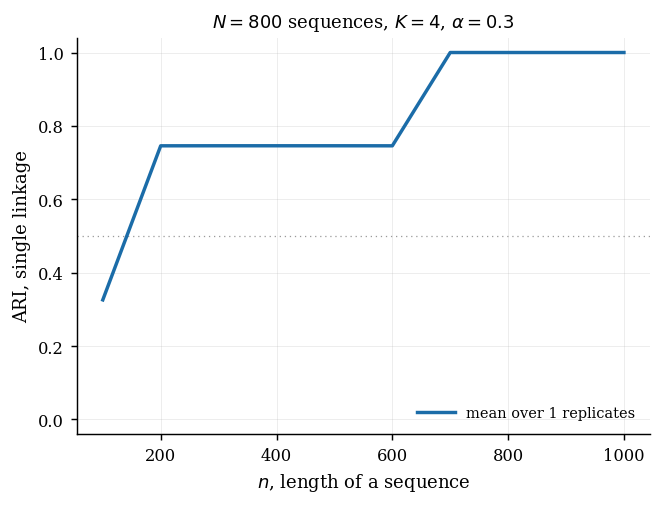

In [9]:
COL_PATH = "#1b6ca8"      # the blue of om_convergence.ipynb


def plot_ari_path(path, filename=None):
    """Sample paths of the ARI against the horizon, at fixed N.

    Same charte as `plot_gamma_convergence` in om_convergence.ipynb: one thin line per
    replicate, the mean over them on top. A replicate is a genuine sample path -- the same N
    sequences read at growing lengths -- so the spread between the thin lines is the
    variability of a single experiment, not an interval around the mean.
    """
    with plt.rc_context(PAPER_STYLE):
        fig, ax = plt.subplots(figsize=(5.2, 4.0))
        ax.plot(path["n"], path["ari"].T, color=COL_PATH, lw=0.6, alpha=0.16)
        ax.plot(path["n"], path["ari"].mean(0), color=COL_PATH, lw=1.9,
                label=rf"mean over {path['ari'].shape[0]} replicates")
        ax.set_xlabel(r"$n$, length of a sequence")
        ax.set_ylabel("ARI, single linkage")
        ax.set_ylim(-0.04, 1.04)
        ax.axhline(0.5, color="0.6", lw=0.7, ls=(0, (1, 3)), zorder=0)
        ax.set_title(rf"$N = {path['N']}$ sequences, $K = {K_FIX}$, $\alpha = {ALPHA_FIX}$",
                     fontsize=10)
        ax.legend(loc="lower right", handlelength=2.6, borderaxespad=0.6)
        fig.tight_layout()
        if filename is not None:
            for ext in ("pdf", "png"):
                fig.savefig(f"Figures/Recovery/{filename}.{ext}", bbox_inches="tight")
            print("figure written to", f"Figures/Recovery/{filename}.pdf")
        plt.show()
    return fig


_ = plot_ari_path(path, filename="ari_path_single_linkage")

## The $(\alpha, K)$ grid

The same grid as `assumptions.ipynb`, so the two sets of heatmaps can be read cell against cell:
$\alpha \in \{0.1, \dots, 10\}$, $K \in \{2, \dots, 10\}$, new chains at every repetition.

**Where it is run.** At the **last point of the path above**. That point is the one where the
curve of experiment 1 has climbed to $\mathrm{ARI} = 1$ on a mixture that is neither easy nor
adversarial, so it is a sample size known to be sufficient for at least one mixture, and the grid
then says how far that conclusion travels across $(\alpha, K)$. Any other choice would put the
grid at a $\lambda$ the curve never visited, and the two figures could not be read together. The
price is that the horizon is no longer the $n = 1500$ of `assumptions.ipynb`: the comparison with
that notebook is at equal $(\alpha, K)$, not at equal sequence length.

This is also where the whole runtime goes — $72$ cells $\times$ $R$ repetitions of an
$N \times N$ matrix, against the handful of matrices the path costs. A cell costs $O(N^2n^2)$ and
does not depend on $K$, so the grid is uniform in price and the trade is entirely between $N$, $n$
and $R$; the budget cell at the top prints the three-way arithmetic.

A single horizon is evaluated. A secondary one would not be free — an alignment is re-run at each
horizon, since nested prefixes share no work — and what it would show, the ARI rising with $n$, is
already read along the path above at eleven lengths rather than two. The bottom rows ($\alpha \le 0.2$, where the relaxation time of the
kernels is largest) remain finite-$n$ statements.

In [10]:
def sweep_ari(alphas, Ks, N, grid, R, seed=SEED + 2):
    """Mean ARI, exact-recovery rate and separation margin on the (alpha, K) grid.

    Returns a dict of (len(alphas), len(Ks), len(grid)) arrays. `ari` and `exact` describe the
    clustering, `margin` and `p_sep` the assumption, all four measured on the same data.
    """
    grid = np.atleast_1d(np.asarray(grid, dtype=np.int64))
    rng = np.random.default_rng(seed)
    shape = (len(alphas), len(Ks), grid.size)
    res = {key: np.empty(shape) for key in ("ari", "exact", "margin", "p_sep", "in", "out",
                                            "ari_medoids", "exact_medoids",
                                            "ari_k_hat", "k_hat", "p_k_hat")}
    for i, alpha in enumerate(tqdm(alphas, desc="alpha")):
        for j, K in enumerate(Ks):
            acc = {key: np.empty((R, grid.size)) for key in EVAL_KEYS}
            for r in range(R):
                mix = sample_mixture(K, N, int(grid[-1]), D_STATES, float(alpha), rng)
                out = evaluate_paths(mix["X"], mix["labels"], grid, K)
                for key in acc:
                    acc[key][r] = out[key]
            m = acc["out"] - acc["in"]
            res["ari"][i, j] = acc["ari"].mean(axis=0)
            res["exact"][i, j] = (acc["ari"] > 1 - EXACT_TOL).mean(axis=0)
            res["margin"][i, j] = np.median(m, axis=0)
            res["p_sep"][i, j] = np.mean(m > 0, axis=0)
            res["in"][i, j] = np.median(acc["in"], axis=0)
            res["out"][i, j] = np.median(acc["out"], axis=0)
            res["ari_medoids"][i, j] = acc["ari_medoids"].mean(axis=0)
            res["exact_medoids"][i, j] = (acc["ari_medoids"] > 1 - EXACT_TOL).mean(axis=0)
            res["ari_k_hat"][i, j] = acc["ari_k_hat"].mean(axis=0)
            res["k_hat"][i, j] = np.median(acc["k_hat"], axis=0)
            res["p_k_hat"][i, j] = np.mean(acc["k_hat"] == K, axis=0)
    return res, grid

In [ ]:
t0 = time.time()
sweep, GRID_N = sweep_ari(ALPHAS, KS, N=N_SWEEP, grid=GRID_N, R=R_SWEEP)
print(f"sweep: {time.time() - t0:.0f}s")

for key, lab in (("ari", "mean ARI"), ("exact", "P(ARI = 1)"), ("p_sep", "P(margin > 0)")):
    Z = sweep[key][:, :, LAST]
    print(f"{lab:16s} in [{Z.min():.2f}, {Z.max():.2f}]")
print(f"{'median margin':16s} in [{sweep['margin'][:, :, LAST].min():+.2f}, "
      f"{sweep['margin'][:, :, LAST].max():+.2f}]")

alpha:   0%|          | 0/8 [00:00<?, ?it/s]

figure written to Figures/Recovery/ari_grid_single_linkage.pdf


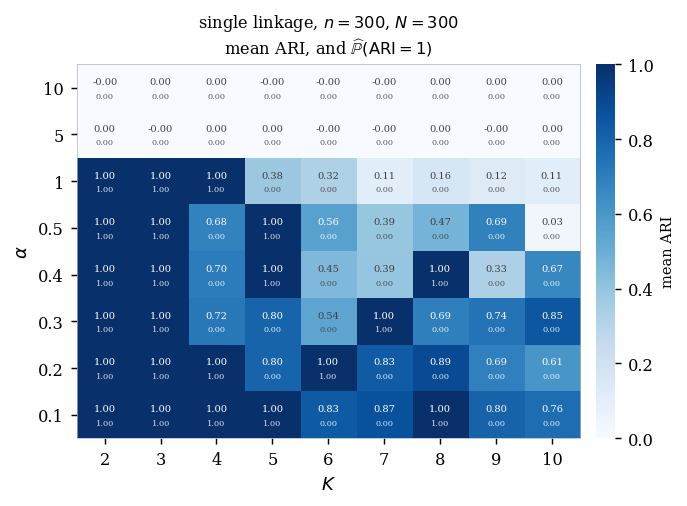

In [ ]:
def _frame(ax, alphas, Ks, title):
    ax.set_xticks(range(len(Ks)), [str(K) for K in Ks])
    ax.set_yticks(range(len(alphas)), [f"{a:g}" for a in alphas])
    ax.set_xlabel(r"$K$")
    ax.set_ylabel(r"$\alpha$")
    ax.set_title(title, fontsize=9, pad=6)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.4)
        spine.set_color("0.7")


def _heat(fig, ax, Z, alphas, Ks, title, cbar_label, below=None, cmap=SEQUENTIAL_CMAP,
          vmin=0.0, vmax=1.0, fmt="{:.2f}", fmt_below="{:+.2f}"):
    """One heatmap of the (alpha, K) grid, optionally annotated with a second quantity below
    the first, in smaller type."""
    im = ax.imshow(Z, origin="lower", aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    _frame(ax, alphas, Ks, title)
    span = max(abs(vmin), abs(vmax))
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            light = (Z[i, j] - vmin) / (vmax - vmin) > 0.55 if cmap == SEQUENTIAL_CMAP \
                else abs(Z[i, j]) > 0.62 * span
            col = "white" if light else "0.25"
            dy = 0.13 if below is not None else 0.0
            ax.text(j, i + dy, fmt.format(Z[i, j]), ha="center", va="center",
                    fontsize=5.5, color=col)
            if below is not None:
                ax.text(j, i - 0.17, fmt_below.format(below[i, j]), ha="center", va="center",
                        fontsize=4.6, color=col, alpha=0.85)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cb.set_label(cbar_label, fontsize=8)
    cb.outline.set_visible(False)
    return im


def plot_ari_grid(sweep, alphas, Ks, n, g=LAST, filename=None):
    """One heatmap of the (alpha, K) grid carrying both clustering summaries.

    Colour and upper figure: the mean ARI, which degrades gracefully and so measures how much
    of the partition is recovered. Lower figure, in smaller type: the probability of exact
    recovery, the event the consistency theorem bounds. The two are read together -- a cell
    can have a high mean ARI and never recover the partition exactly, which is the union bound
    over the C(N, 2) pairs at work.

    The separation margin is deliberately not shown. It is still measured on the same
    repetitions and available in `sweep["margin"]`, but it belongs to the assumption rather
    than to the performance, and `assumptions.ipynb` reports it on this very grid.
    """
    with plt.rc_context(PAPER_STYLE):
        fig, ax = plt.subplots(figsize=(5.4, 4.0))
        _heat(fig, ax, sweep["ari"][:, :, g], alphas, Ks,
              rf"single linkage, $n = {n}$, $N = {N_SWEEP}$"
              "\n" rf"mean ARI, and $\widehat{{\mathbb{{P}}}}(\mathrm{{ARI}} = 1)$",
              "mean ARI", below=sweep["exact"][:, :, g], fmt_below="{:.2f}")
        fig.tight_layout()
        if filename is not None:
            for ext in ("pdf", "png"):
                fig.savefig(f"Figures/Recovery/{filename}.{ext}", bbox_inches="tight")
            print("figure written to", f"Figures/Recovery/{filename}.pdf")
        plt.show()
    return fig


_ = plot_ari_grid(sweep, ALPHAS, KS, int(GRID_N[LAST]), g=LAST,
                  filename="ari_grid_single_linkage")

## Estimating $K$: the largest-gap rule

Everything above assumes $K$ known. That is what the consistency theorem is stated for, and
cutting the tree at $K$ blocks avoids the oracle threshold $t \in (\Delta_{\mathrm{in}},
\Delta_{\mathrm{out}})$ that no practitioner could pick. It is still an assumption, so this last
section drops it.

The **largest-gap estimator** (equation (4.4)) reads $K$ off the merge heights themselves,
$\hat K = N - \arg\max_{1 \le \ell \le N-2} (h_{\ell+1} - h_\ell)$: the dendrogram is cut where it
opens widest. It costs nothing here — `single_linkage_tree` already returns the heights, so both
partitions are scored on the *same* tree, on the *same* data as everything else.

What the theory says to expect. The largest-gap rule is not covered by Assumption 3 but by
**Assumption 4** (strong separation), in either of its forms $\Delta_{\mathrm{out}} >
2\Delta_{\mathrm{in}}$ or $2\Delta_{\mathrm{out}} > \Delta_{\mathrm{out}}^{\max} +
\Delta_{\mathrm{in}}$ — conditions `assumptions.ipynb` found essentially confined to $K = 2$:
4(a) peaks at $0.78$ at $(\alpha, K) = (0.1, 2)$ and is zero for $K \ge 4$. The prediction is
therefore that $\hat K$ collapses well before the ARI at known $K$ does, and the two panels below
measure the gap between the two.

Three quantities are reported: $\hat{\mathbb P}(\hat K = K)$, the ARI of the partition cut at
$\hat K$, and the median $\hat K$ itself — the last one says *how* the rule fails, which the first
two cannot.

figure written to Figures/Recovery/k_hat_grid.pdf


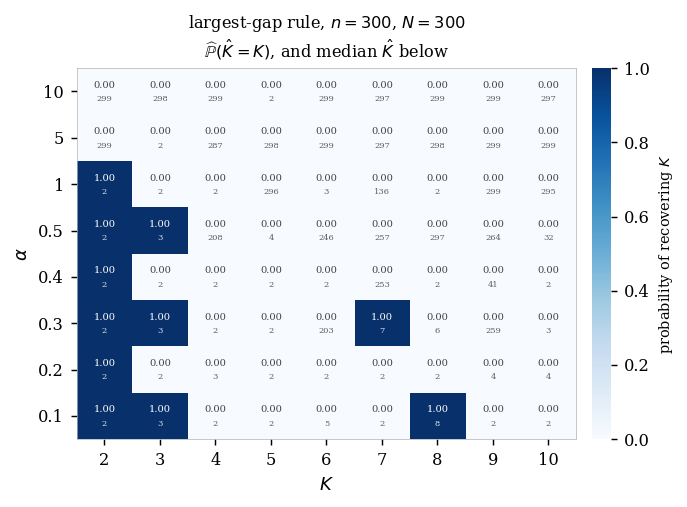

   K  P(Khat = K)  median Khat   ARI | K  ARI | Khat    loss
   2         0.75            2      0.75        0.75    0.00
   3         0.38            2      0.75        0.59    0.16
   4         0.00            2      0.64        0.30    0.34
   5         0.00            2      0.62        0.23    0.39
   6         0.00          104      0.46        0.29    0.17
   7         0.12          194      0.45        0.29    0.16
   8         0.12            7      0.53        0.24    0.29
   9         0.00          262      0.42        0.22    0.20
  10         0.00           18      0.38        0.11    0.27


In [ ]:
def plot_k_hat_grid(sweep, alphas, Ks, n, g=LAST, filename=None):
    """How often the largest-gap rule recovers K, over the (alpha, K) grid.

    Colour and upper figure: the probability of hitting K exactly. Lower figure: the median
    Khat, which says *how* the rule fails and not merely that it does. The ARI achieved at
    Khat is still measured -- it is in `sweep["ari_k_hat"]`, and the table below prints it
    against the ARI at known K -- but it is not drawn: the question here is whether K itself
    is recoverable.
    """
    with plt.rc_context(PAPER_STYLE):
        fig, ax = plt.subplots(figsize=(5.4, 4.0))
        _heat(fig, ax, sweep["p_k_hat"][:, :, g], alphas, Ks,
              rf"largest-gap rule, $n = {n}$, $N = {N_SWEEP}$"
              "\n" rf"$\widehat{{\mathbb{{P}}}}(\hat K = K)$, and median $\hat K$ below",
              "probability of recovering $K$", below=sweep["k_hat"][:, :, g],
              fmt_below="{:.0f}")
        fig.tight_layout()
        if filename is not None:
            for ext in ("pdf", "png"):
                fig.savefig(f"Figures/Recovery/{filename}.{ext}", bbox_inches="tight")
            print("figure written to", f"Figures/Recovery/{filename}.pdf")
        plt.show()
    return fig


_ = plot_k_hat_grid(sweep, ALPHAS, KS, int(GRID_N[LAST]), g=LAST, filename="k_hat_grid")

# the price of not knowing K, per K, averaged over alpha
print(f"{'K':>4}{'P(Khat = K)':>13}{'median Khat':>13}{'ARI | K':>10}{'ARI | Khat':>12}"
      f"{'loss':>8}")
for j, K in enumerate(KS):
    a_known = sweep["ari"][:, j, LAST].mean()
    a_hat = sweep["ari_k_hat"][:, j, LAST].mean()
    print(f"{K:>4}{sweep['p_k_hat'][:, j, LAST].mean():>13.2f}"
          f"{np.median(sweep['k_hat'][:, j, LAST]):>13.0f}"
          f"{a_known:>10.2f}{a_hat:>12.2f}{a_known - a_hat:>8.2f}")

In [ ]:
print(f"{'n':>7}{'ARI | K':>10}{'ARI | Khat':>12}"
      f"{'median Khat':>13}{'P(Khat = K)':>13}")
for t in range(path["n"].size):
    print(f"{path['n'][t]:>7}"
          f"{path['ari'][:, t].mean():>10.3f}{path['ari_k_hat'][:, t].mean():>12.3f}"
          f"{np.median(path['k_hat'][:, t]):>13.0f}"
          f"{np.mean(path['k_hat'][:, t] == K_FIX):>13.2f}")


def plot_k_hat_path(path, filename=None):
    """What knowing K is worth, along the path.

    Left: the ARI of the cut at K and of the cut at Khat, all replicates as thin lines and the
    mean on top, the charte of om_convergence.ipynb. Right: how often the largest-gap rule hits
    K, and the median Khat it returns otherwise.
    """
    n = path["n"]
    with plt.rc_context(PAPER_STYLE):
        fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.8))
        for key, col, lab in (("ari", COL_PATH, r"$K$ known"),
                              ("ari_k_hat", COL_GAP, r"$\hat K$, largest gap")):
            axes[0].plot(n, path[key].T, color=col, lw=0.6, alpha=0.12)
            axes[0].plot(n, path[key].mean(0), color=col, lw=1.9, label=lab)
        axes[0].set_ylabel("ARI, single linkage")
        axes[0].set_ylim(-0.04, 1.04)
        axes[0].axhline(0.5, color="0.6", lw=0.7, ls=(0, (1, 3)), zorder=0)
        axes[0].legend(loc="lower right", handlelength=2.6)

        axes[1].plot(n, (path["k_hat"] == K_FIX).mean(0), color=COL_GAP, lw=1.9)
        axes[1].set_ylim(-0.04, 1.04)
        axes[1].set_ylabel(r"$\hat{\mathbb{P}}(\hat K = K)$", color=COL_GAP)
        twin = axes[1].twinx()
        twin.plot(n, np.median(path["k_hat"], axis=0), color="0.35", lw=1.2, ls=(0, (4, 2)))
        twin.axhline(K_FIX, color="0.35", lw=0.7, ls=(0, (1, 3)))
        twin.set_ylabel(r"median $\hat K$   (dashed; dotted line $= K$)", fontsize=8)
        twin.grid(False)
        for ax in axes:
            ax.set_xlabel(r"$n$")
        fig.suptitle(rf"$K = {K_FIX}$, $\alpha = {ALPHA_FIX}$, $N = {path['N']}$, "
                     rf"{path['ari'].shape[0]} replicates", fontsize=9)
        fig.tight_layout(rect=(0, 0, 1, 0.95))
        if filename is not None:
            for ext in ("pdf", "png"):
                fig.savefig(f"Figures/Recovery/{filename}.{ext}", bbox_inches="tight")
            print("figure written to", f"Figures/Recovery/{filename}.pdf")
        plt.show()
    return fig


_ = plot_k_hat_path(path, filename="k_hat_path")

## $K$-medoids on the same matrices

Single linkage is not the only estimator the paper studies. $K$-medoids minimises

$$\Phi_{N,n}(m) = \sum_{i=1}^{N} \min_{1 \le k \le K} d_{\mathrm{OM}}(X_i, m_k)$$

over the medoid sets $m = (m_1,\dots,m_K)$, and its consistency needs **Assumption 5**
(balance), $\Delta_{\mathrm{out}} > (1 + w_{\max}/w_{\min})\,\Delta_{\mathrm{in}}$ — with the
balanced weights used throughout this notebook, $\Delta_{\mathrm{out}} > 2\Delta_{\mathrm{in}}$,
which is exactly Assumption 4(a) and far more demanding than the
$\Delta_{\mathrm{out}} > \Delta_{\mathrm{in}}$ single linkage needs. Comparing the two on the
*same data*, the *same* dissimilarity matrices and the *same* repetitions is therefore the cleanest
way to see what the stronger assumption buys, or costs.

It is free: the matrices are already computed, and the medoid search is a few hundredths of a
second against the tens of seconds one matrix costs.

**The minimisation is heuristic, and that is the one caveat.** The theorem is about the *global*
minimiser of $\Phi_{N,n}$, which would need the $\binom{N}{K}$ medoid sets enumerated —
$\binom{800}{4} = 1.7\cdot10^{10}$, out of reach. `om_lib.kmedoids` therefore runs PAM's
deterministic BUILD, then alternates between reassignment and within-cluster re-centring until the
medoid set is stable, and keeps the best of `MED_RESTARTS` runs. The script
`check_clustering.py` checks it against `om_lib.kmedoids_exhaustive` wherever enumeration is
affordable, and checks single linkage against `scipy` and the ARI against `sklearn` while it is at
it; where a discrepancy appears, what is being measured is the failure of the heuristic and not the
violation of the assumption.

**One thing this does not do.** The weights are balanced at every point, so $w_{\max}/w_{\min} = 1$
throughout: this probes Assumption 5 at its most favourable setting, not along the axis the
condition is really about. Varying $w_{\max}/w_{\min}$ until
$A = w_{\min}(\Delta_{\mathrm{out}}-\Delta_{\mathrm{in}}) - w_{\max}\Delta_{\mathrm{in}}$ changes
sign, with single linkage as the control, remains a separate experiment.

In [ ]:
def plot_medoids_path(path, filename=None):
    """Single linkage against K-medoids along the path, same data, same matrices.

    All replicate curves as thin lines with the mean on top, the charte of
    om_convergence.ipynb. The two estimators differ only in how they read the matrix, so the
    vertical gap at a given abscissa is attributable to the algorithm alone.
    """
    n = path["n"]
    with plt.rc_context(PAPER_STYLE):
        fig, ax = plt.subplots(figsize=(5.2, 4.0))
        for key, col, lab in (("ari", COL_PATH, "single linkage"),
                              ("ari_medoids", COL_GAP, r"$K$-medoids")):
            ax.plot(n, path[key].T, color=col, lw=0.6, alpha=0.12)
            ax.plot(n, path[key].mean(0), color=col, lw=1.9, label=lab)
        ax.set_xlabel(r"$n$")
        ax.set_ylabel("mean ARI")
        ax.set_ylim(-0.04, 1.04)
        ax.axhline(0.5, color="0.6", lw=0.7, ls=(0, (1, 3)), zorder=0)
        ax.set_title(rf"$K = {K_FIX}$, $\alpha = {ALPHA_FIX}$, $N = {path['N']}$, "
                     rf"{path['ari'].shape[0]} replicates", fontsize=10)
        ax.legend(loc="lower right", handlelength=2.6)
        fig.tight_layout()
        if filename is not None:
            for ext in ("pdf", "png"):
                fig.savefig(f"Figures/Recovery/{filename}.{ext}", bbox_inches="tight")
            print("figure written to", f"Figures/Recovery/{filename}.pdf")
        plt.show()
    return fig


print(f"{'n':>7}{'ARI single':>12}{'ARI medoids':>13}{'gap':>8}")
for t in range(path["n"].size):
    a, b = path["ari"][:, t].mean(), path["ari_medoids"][:, t].mean()
    print(f"{path['n'][t]:>7}"
          f"{a:>12.3f}{b:>13.3f}{a - b:>+8.3f}")

_ = plot_medoids_path(path, filename="medoids_path")

In [ ]:
def plot_medoids_grid(sweep, alphas, Ks, n, g=LAST, filename=None):
    """K-medoids over the (alpha, K) grid, in the same charte as the single-linkage grid.

    Colour and upper figure: the mean ARI. Lower figure: the probability of exact recovery.
    Reading it against `ari_grid_single_linkage`, cell by cell, is what says whether the
    stronger assumption K-medoids needs shows up as a loss of performance.
    """
    with plt.rc_context(PAPER_STYLE):
        fig, ax = plt.subplots(figsize=(5.4, 4.0))
        _heat(fig, ax, sweep["ari_medoids"][:, :, g], alphas, Ks,
              rf"$K$-medoids, $n = {n}$, $N = {N_SWEEP}$"
              "\n" rf"mean ARI, and $\widehat{{\mathbb{{P}}}}(\mathrm{{ARI}} = 1)$ below",
              "mean ARI", below=sweep["exact_medoids"][:, :, g], fmt_below="{:.2f}")
        fig.tight_layout()
        if filename is not None:
            for ext in ("pdf", "png"):
                fig.savefig(f"Figures/Recovery/{filename}.{ext}", bbox_inches="tight")
            print("figure written to", f"Figures/Recovery/{filename}.pdf")
        plt.show()
    return fig


_ = plot_medoids_grid(sweep, ALPHAS, KS, int(GRID_N[LAST]), g=LAST, filename="medoids_grid")

# what the stronger assumption costs, per K, averaged over alpha
print(f"{'K':>4}{'ARI single':>12}{'ARI medoids':>13}{'gap':>8}"
      f"{'P(=1) single':>14}{'P(=1) medoids':>15}")
for j, K in enumerate(KS):
    a, b = sweep["ari"][:, j, LAST].mean(), sweep["ari_medoids"][:, j, LAST].mean()
    print(f"{K:>4}{a:>12.2f}{b:>13.2f}{a - b:>+8.2f}"
          f"{sweep['exact'][:, j, LAST].mean():>14.2f}"
          f"{sweep['exact_medoids'][:, j, LAST].mean():>15.2f}")